# Week 3a: NumPy — Numerical Computing with Python

# Applied Statistics with Python (2026)

---

NumPy (Numerical Python) is the **foundation** of the entire Python data science stack.  
Pandas, Matplotlib, scikit-learn, PyTorch — they all build on NumPy.

### What We'll Cover

| # | Topic |
|---|-------|
| 1 | Why NumPy? Python Lists vs NumPy Arrays |
| 2 | Creating Arrays |
| 3 | Array Attributes |
| 4 | Indexing & Slicing |
| 5 | Vectorized Operations |
| 6 | Broadcasting |
| 7 | Aggregation Functions |
| 8 | Reshaping & Stacking |
| 9 | Random Number Generation |
| 10 | Linear Algebra Basics |
| 11 | Practical Example: Exam Score Analysis |

In [1]:
import numpy as np
print(f"NumPy version: {np.__version__}")

NumPy version: 2.2.5


In [2]:
pip install numpy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install numpy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


---
## 1. Why NumPy?

### The Problem with Python Lists

Python lists are **flexible** (can mix types) but **slow** for numerical computation.  
This is because each element in a list is a full Python object stored at a separate memory location.

NumPy solves this by storing data in **contiguous memory blocks** with a **fixed type**, just like arrays in C or Fortran.

| Feature | Python List | NumPy Array |
|---------|-------------|-------------|
| Element types | Mixed | Homogeneous (same type) |
| Memory | Scattered objects | Contiguous block |
| Speed | Slow (Python loops) | Fast (C-compiled) |
| Math operations | Manual loops | Vectorized (element-wise) |
| Size | Flexible | Fixed after creation |

Let's **measure the speed difference** — adding two arrays of 1 million numbers.

In [4]:
import time

size = 1_000_000

# --- Python list approach ---
list_a = list(range(size))
list_b = list(range(size))

start = time.time()
list_c = [a + b for a, b in zip(list_a, list_b)]
list_time = time.time() - start

# --- NumPy approach ---
arr_a = np.arange(size)
arr_b = np.arange(size)

start = time.time()
arr_c = arr_a + arr_b
numpy_time = time.time() - start

print(f"Python list: {list_time:.4f} seconds")
print(f"NumPy array: {numpy_time:.4f} seconds")
print(f"NumPy is {list_time / numpy_time:.0f}x faster!")

Python list: 0.0172 seconds
NumPy array: 0.0006 seconds
NumPy is 28x faster!


> **Key Insight:** NumPy is typically **10–100x faster** than Python lists for numerical operations.  
> This difference matters when you work with real datasets (millions of rows).

---
## 2. Creating Arrays

The core object in NumPy is the **`ndarray`** (n-dimensional array).  
There are many ways to create one.

### 2.1 From Python Lists

The most direct way — pass a Python list to `np.array()`.

In [5]:
# 1D array (vector)
scores = np.array([78, 92, 85, 67, 95, 88, 72, 90])
print(f"scores = {scores}")
print(f"type   = {type(scores)}")
print(f"dtype  = {scores.dtype}")

scores = [78 92 85 67 95 88 72 90]
type   = <class 'numpy.ndarray'>
dtype  = int64


Create a **2D array** (matrix) from a list of lists — each inner list becomes a row.

In [6]:
# 2D array (matrix)
matrix = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])
print(f"matrix =\n{matrix}")
print(f"shape  = {matrix.shape}")

matrix =
[[1 2 3]
 [4 5 6]
 [7 8 9]]
shape  = (3, 3)


You can **specify the data type** explicitly with the `dtype` parameter.

In [7]:
# Specify data type
a = np.array([1, 2, 3], dtype=float)
print(f"float array: {a}, dtype={a.dtype}")

b = np.array([1.7, 2.3, 3.9], dtype=int)
print(f"int array:   {b}, dtype={b.dtype}")  # Truncated, not rounded!

float array: [1. 2. 3.], dtype=float64
int array:   [1 2 3], dtype=int64


### 2.2 Built-in Array Generators

NumPy provides many convenient functions to create arrays without typing out every element.

`np.zeros()` and `np.ones()` — create arrays filled with 0s or 1s. Useful for initialization.

In [8]:
# Zeros and ones
print(f"zeros(5):    {np.zeros(5)}")
print(f"ones(5):     {np.ones(5)}")
print(f"full(5, 42): {np.full(5, 42)}")

# 2D versions
print(f"\nzeros(2,3) =\n{np.zeros((2, 3))}")
print(f"\nones(3,2) =\n{np.ones((3, 2))}")

zeros(5):    [0. 0. 0. 0. 0.]
ones(5):     [1. 1. 1. 1. 1.]
full(5, 42): [42 42 42 42 42]

zeros(2,3) =
[[0. 0. 0.]
 [0. 0. 0.]]

ones(3,2) =
[[1. 1.]
 [1. 1.]
 [1. 1.]]


`np.arange()` — like Python's `range()` but returns a NumPy array. Supports float step sizes.

In [9]:
# arange: like range() but returns an array
print(f"arange(10):       {np.arange(10)}")
print(f"arange(2, 10):    {np.arange(2, 10)}")
print(f"arange(0, 1, 0.2): {np.arange(0, 1, 0.2)}")

arange(10):       [0 1 2 3 4 5 6 7 8 9]
arange(2, 10):    [2 3 4 5 6 7 8 9]
arange(0, 1, 0.2): [0.  0.2 0.4 0.6 0.8]


`np.linspace()` — create evenly spaced numbers over a specified range. You specify the **number of points**, not the step size. This is essential for plotting smooth curves.

In [10]:
# linspace: specify number of points (includes both endpoints)
print(f"linspace(0, 1, 5):   {np.linspace(0, 1, 5)}")
print(f"linspace(0, 10, 6):  {np.linspace(0, 10, 6)}")
print(f"linspace(0, 2π, 5):  {np.linspace(0, 2*np.pi, 5)}")

linspace(0, 1, 5):   [0.   0.25 0.5  0.75 1.  ]
linspace(0, 10, 6):  [ 0.  2.  4.  6.  8. 10.]
linspace(0, 2π, 5):  [0.         1.57079633 3.14159265 4.71238898 6.28318531]


`np.eye()` creates an **identity matrix** — 1s on the diagonal, 0s elsewhere. Important in linear algebra.

In [11]:
# Identity matrix
I = np.eye(4)
print(f"Identity matrix (4×4):\n{I}")

Identity matrix (4×4):
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


---
## 3. Array Attributes

Every NumPy array carries metadata that describes its structure. Understanding these attributes is essential for debugging and data manipulation.

In [9]:
arr = np.array([[1, 2, 3, 4],
                [5, 6, 7, 8],
                [9, 10, 11, 12]])

print(f"Array:\n{arr}")
print(f"\nshape:  {arr.shape}")    # (rows, cols) → (3, 4)
print(f"ndim:   {arr.ndim}")       # Number of dimensions
print(f"size:   {arr.size}")       # Total number of elements
print(f"dtype:  {arr.dtype}")      # Data type of elements
print(f"nbytes: {arr.nbytes}")     # Total memory in bytes

Array:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

shape:  (3, 4)
ndim:   2
size:   12
dtype:  int64
nbytes: 96


**Understanding `shape`** — this is the single most important attribute:

| Array | Shape | Meaning |
|-------|-------|---------|
| `[1, 2, 3]` | `(3,)` | 1D array with 3 elements |
| `[[1,2],[3,4]]` | `(2, 2)` | 2D array: 2 rows × 2 columns |
| `[[[1,2],[3,4]],[[5,6],[7,8]]]` | `(2, 2, 2)` | 3D array: 2 blocks × 2 rows × 2 cols |

---
## 4. Indexing & Slicing

NumPy indexing extends Python's list indexing to multiple dimensions.  
Mastering this is critical — you'll use it every day in data analysis.

### 4.1 1D Array Indexing

Works just like Python lists — zero-based, supports negative indices and slicing.

In [13]:
arr = np.array([10, 20, 30, 40, 50, 60, 70, 80])

print(f"Array:     {arr}")
print(f"arr[0]:    {arr[0]}")
print(f"arr[-1]:   {arr[-1]}")
print(f"arr[2:5]:  {arr[2:5]}")
print(f"arr[:3]:   {arr[:3]}")
print(f"arr[::2]:  {arr[::2]}")
print(f"arr[::-1]: {arr[::-1]}")

Array:     [10 20 30 40 50 60 70 80]
arr[0]:    10
arr[-1]:   80
arr[2:5]:  [30 40 50]
arr[:3]:   [10 20 30]
arr[::2]:  [10 30 50 70]
arr[::-1]: [80 70 60 50 40 30 20 10]


### 4.2 2D Array Indexing

For 2D arrays, use `arr[row, col]`. Think of it as a spreadsheet: **row first, column second**.

In [14]:
# Student scores: 4 students × 3 exams
data = np.array([
    [85, 90, 78],   # Alice
    [92, 88, 95],   # Bob
    [67, 72, 70],   # Charlie
    [78, 85, 80],   # Diana
])
students = ["Alice", "Bob", "Charlie", "Diana"]
exams = ["Midterm", "Final", "Project"]

print(f"Data shape: {data.shape}  (4 students × 3 exams)")
print(f"\nFull data:\n{data}")

Data shape: (4, 3)  (4 students × 3 exams)

Full data:
[[85 90 78]
 [92 88 95]
 [67 72 70]
 [78 85 80]]


Access **individual elements** with `[row, col]`, **entire rows** with `[row, :]`, and **entire columns** with `[:, col]`.

In [15]:
# Single element: Alice's Final score
print(f"Alice's Final: {data[0, 1]}")

# Entire row: Bob's all scores
print(f"Bob's scores:  {data[1, :]}")
print(f"Bob's scores:  {data[1]}")

# Entire column: all Midterm scores
print(f"Midterm scores: {data[:, 0]}")

# Sub-matrix: first 2 students, last 2 exams
print(f"Sub-matrix:\n{data[:2, 1:]}")

Alice's Final: 90
Bob's scores:  [92 88 95]
Bob's scores:  [92 88 95]
Midterm scores: [85 92 67 78]
Sub-matrix:
[[90 78]
 [88 95]]


### 4.3 Boolean Indexing (Filtering)

This is one of NumPy's most powerful features. You can use a **boolean condition** to select elements that satisfy a criterion — no loops needed!

In [16]:
scores = np.array([78, 92, 85, 67, 95, 88, 72, 90, 45, 83])

# Step 1: create a boolean mask
mask = scores >= 80
print(f"Scores:  {scores}")
print(f"Mask:    {mask}")

# Step 2: use the mask to filter
high_scores = scores[mask]
print(f"\nHigh scores (≥80): {high_scores}")

# Usually done in one line
print(f"Failing (<60): {scores[scores < 60]}")
print(f"B range (80-89): {scores[(scores >= 80) & (scores < 90)]}")

Scores:  [78 92 85 67 95 88 72 90 45 83]
Mask:    [False  True  True False  True  True False  True False  True]

High scores (≥80): [92 85 95 88 90 83]
Failing (<60): [45]
B range (80-89): [85 88 83]


> **Important:** Use `&` (and), `|` (or), `~` (not) for combining boolean masks.  
> Do **NOT** use Python's `and`, `or`, `not` — they don't work element-wise on arrays.

### 4.4 Fancy Indexing

Use a **list of indices** to pick specific elements in any order — like cherry-picking rows or columns.

In [17]:
scores = np.array([78, 92, 85, 67, 95, 88, 72, 90])

# Pick specific indices
indices = [0, 3, 5]
print(f"Scores at indices {indices}: {scores[indices]}")

# Works with 2D too — select specific rows
data = np.array([
    [85, 90, 78],
    [92, 88, 95],
    [67, 72, 70],
    [78, 85, 80],
])

# Get rows 0 and 3 (Alice and Diana)
selected = data[[0, 3]]
print(f"\nSelected rows:\n{selected}")

Scores at indices [0, 3, 5]: [78 67 88]

Selected rows:
[[85 90 78]
 [78 85 80]]


### 4.5 Important: Views vs Copies

**Slicing** creates a **view** (shared memory) — changes affect the original!  
**Fancy indexing** and **boolean indexing** create a **copy** (independent memory).

In [11]:
original = np.array([1, 2, 3, 4, 5])

# Slice → view (shared memory)
view = original[:3]
view[0] = 999
print(f"After modifying view: original = {original}")  # Original changed!

# To get an independent copy, use .copy()
original = np.array([1, 2, 3, 4, 5])
copy = original[:3].copy()
copy[0] = 999
print(f"After modifying copy: original = {original}")   # Original unchanged!

After modifying view: original = [999   2   3   4   5]
After modifying copy: original = [1 2 3 4 5]


---
## 5. Vectorized Operations

### The Core Idea

In Python, to add two lists element-by-element, you need a loop.  
In NumPy, mathematical operations are automatically applied **element-by-element** — this is called **vectorization**.

Vectorized code is:
1. **Faster** — runs in compiled C, not interpreted Python
2. **Cleaner** — no loops, just math expressions
3. **Safer** — fewer bugs from loop logic

**Arithmetic operations** are applied element-by-element. Each operator works on every pair of corresponding elements.

In [12]:
a = np.array([10, 20, 30, 40])
b = np.array([1, 2, 3, 4])

print(f"a = {a}")
print(f"b = {b}")
print(f"a + b = {a + b}")
print(f"a - b = {a - b}")
print(f"a * b = {a * b}")
print(f"a / b = {a / b}")
print(f"a ** 2 = {a ** 2}")
print(f"a % 3  = {a % 3}")

a = [10 20 30 40]
b = [1 2 3 4]
a + b = [11 22 33 44]
a - b = [ 9 18 27 36]
a * b = [ 10  40  90 160]
a / b = [10. 10. 10. 10.]
a ** 2 = [ 100  400  900 1600]
a % 3  = [1 2 0 1]


**Comparison operators** also work element-wise, returning a boolean array.

In [20]:
scores = np.array([78, 92, 85, 67, 95, 88])

print(f"scores > 80:  {scores > 80}")
print(f"scores == 85: {scores == 85}")
print(f"scores != 67: {scores != 67}")

scores > 80:  [False  True  True False  True  True]
scores == 85: [False False  True False False False]
scores != 67: [ True  True  True False  True  True]


**NumPy math functions** (universal functions, or `ufuncs`) operate element-wise on arrays.

In [13]:
x = np.array([0, np.pi/6, np.pi/4, np.pi/3, np.pi/2])

print(f"x (radians): {x}")
print(f"sin(x):      {np.sin(x)}")
print(f"cos(x):      {np.cos(x)}")
print(f"exp(x):      {np.exp(x)}")
print(f"sqrt([4,9,16,25]): {np.sqrt(np.array([4, 9, 16, 25]))}")
print(f"log([1,e,e²]):     {np.log(np.array([1, np.e, np.e**2]))}")

x (radians): [0.         0.52359878 0.78539816 1.04719755 1.57079633]
sin(x):      [0.         0.5        0.70710678 0.8660254  1.        ]
cos(x):      [1.00000000e+00 8.66025404e-01 7.07106781e-01 5.00000000e-01
 6.12323400e-17]
exp(x):      [1.         1.68809179 2.19328005 2.84965391 4.81047738]
sqrt([4,9,16,25]): [2. 3. 4. 5.]
log([1,e,e²]):     [0. 1. 2.]


**Practical example:** convert exam scores to z-scores (standard scores). The z-score tells you how many standard deviations each score is from the mean.

$$z = \frac{x - \mu}{\sigma}$$

In [22]:
scores = np.array([78, 92, 85, 67, 95, 88, 72, 90, 83, 76])

mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std  # Vectorized!

print(f"Scores:   {scores}")
print(f"Mean:     {mean:.2f}")
print(f"Std:      {std:.2f}")
print(f"Z-scores: {np.round(z_scores, 2)}")

Scores:   [78 92 85 67 95 88 72 90 83 76]
Mean:     82.60
Std:      8.67
Z-scores: [-0.53  1.08  0.28 -1.8   1.43  0.62 -1.22  0.85  0.05 -0.76]


---
## 6. Broadcasting

### What Is Broadcasting?

Broadcasting is NumPy's mechanism for performing operations on arrays of **different shapes**.  
Instead of requiring arrays to be the same size, NumPy "stretches" the smaller array to match.

### Broadcasting Rules

NumPy compares shapes **from right to left**. Two dimensions are compatible if:
1. They are **equal**, OR
2. One of them is **1**

```
Shape (3, 4) + Shape (4,)    → OK (4 == 4)
Shape (3, 4) + Shape (3, 1)  → OK (1 broadcasts to 4)
Shape (3, 4) + Shape (3,)    → ERROR (4 ≠ 3)
```

**Scalar broadcasting** — the simplest case: a scalar is "stretched" to match the entire array.

In [23]:
# Scalar + Array: scalar is broadcast to every element
scores = np.array([78, 85, 92, 67, 90])

# Add 5 bonus points to every score
curved = scores + 5
print(f"Original: {scores}")
print(f"Curved:   {curved}")

# Convert to percentage (out of 100)
pct = scores / 100 * 100
print(f"Percent:  {pct}")

Original: [78 85 92 67 90]
Curved:   [83 90 97 72 95]
Percent:  [78. 85. 92. 67. 90.]


**1D + 2D broadcasting** — a 1D array is broadcast across each row (or column) of a 2D array.

In [24]:
# 2D + 1D: the 1D array is broadcast across each row
# 4 students × 3 exams
scores = np.array([
    [85, 90, 78],   # Alice
    [92, 88, 95],   # Bob
    [67, 72, 70],   # Charlie
    [78, 85, 80],   # Diana
])

# Weights for each exam: Midterm=30%, Final=50%, Project=20%
weights = np.array([0.3, 0.5, 0.2])

# Multiply each column by its weight (broadcasts across rows)
weighted = scores * weights   # shape (4,3) * shape (3,) → (4,3)
print(f"Weighted scores:\n{weighted}")

# Final weighted average for each student
final = weighted.sum(axis=1)
students = ["Alice", "Bob", "Charlie", "Diana"]
for name, score in zip(students, final):
    print(f"{name:10s} weighted average: {score:.1f}")

Weighted scores:
[[25.5 45.  15.6]
 [27.6 44.  19. ]
 [20.1 36.  14. ]
 [23.4 42.5 16. ]]
Alice      weighted average: 86.1
Bob        weighted average: 90.6
Charlie    weighted average: 70.1
Diana      weighted average: 81.9


**Column broadcasting** — use `.reshape()` or `[:, np.newaxis]` to broadcast along columns.

In [25]:
# Subtract each student's mean score (center the data)
student_means = scores.mean(axis=1)  # shape (4,)
print(f"Student means: {student_means}")

# Need to reshape to (4, 1) for column-wise broadcasting
centered = scores - student_means[:, np.newaxis]  # (4,3) - (4,1) → (4,3)
print(f"\nCentered scores:\n{centered}")
print(f"Row means (should be ~0): {centered.mean(axis=1).round(10)}")

Student means: [84.33333333 91.66666667 69.66666667 81.        ]

Centered scores:
[[ 0.66666667  5.66666667 -6.33333333]
 [ 0.33333333 -3.66666667  3.33333333]
 [-2.66666667  2.33333333  0.33333333]
 [-3.          4.         -1.        ]]
Row means (should be ~0): [ 0. -0. -0.  0.]


---
## 7. Aggregation Functions

Aggregation reduces an array to a single value (or reduces one dimension).  
The **`axis`** parameter is the key concept here.

For a 2D array with shape `(rows, cols)`:
- `axis=0` → aggregate **down columns** (collapse rows) → result has shape `(cols,)`
- `axis=1` → aggregate **across rows** (collapse columns) → result has shape `(rows,)`
- `axis=None` (default) → aggregate the **entire array** → single value

**Memory trick:** `axis=0` eliminates the **first** dimension (rows), `axis=1` eliminates the **second** dimension (columns).

All common statistical aggregation functions demonstrated on a student scores matrix.

In [26]:
# 4 students × 3 exams
scores = np.array([
    [85, 90, 78],   # Alice
    [92, 88, 95],   # Bob
    [67, 72, 70],   # Charlie
    [78, 85, 80],   # Diana
])
students = ["Alice", "Bob", "Charlie", "Diana"]
exams = ["Midterm", "Final", "Project"]

print("--- Global ---")
print(f"Overall mean: {scores.mean():.1f}")
print(f"Overall std:  {scores.std():.1f}")

print("\n--- Per exam (axis=0, aggregate down columns) ---")
for exam, avg in zip(exams, scores.mean(axis=0)):
    print(f"{exam:10s} mean = {avg:.1f}")

print("\n--- Per student (axis=1, aggregate across rows) ---")
for name, avg in zip(students, scores.mean(axis=1)):
    print(f"{name:10s} mean = {avg:.1f}")

--- Global ---
Overall mean: 81.7
Overall std:  8.6

--- Per exam (axis=0, aggregate down columns) ---
Midterm    mean = 80.5
Final      mean = 83.8
Project    mean = 80.8

--- Per student (axis=1, aggregate across rows) ---
Alice      mean = 84.3
Bob        mean = 91.7
Charlie    mean = 69.7
Diana      mean = 81.0


Here is a complete list of the most commonly used aggregation functions.

In [27]:
data = np.array([78, 92, 85, 67, 95, 88, 72, 90, 83, 76])

print(f"Data:    {data}")
print(f"sum:     {np.sum(data)}")
print(f"mean:    {np.mean(data):.2f}")
print(f"median:  {np.median(data):.2f}")
print(f"std:     {np.std(data):.2f}")
print(f"var:     {np.var(data):.2f}")
print(f"min:     {np.min(data)}")
print(f"max:     {np.max(data)}")
print(f"argmin:  {np.argmin(data)}  (index of min)")
print(f"argmax:  {np.argmax(data)}  (index of max)")
print(f"cumsum:  {np.cumsum(data)}")

# Percentiles
print(f"\n25th percentile (Q1): {np.percentile(data, 25):.2f}")
print(f"50th percentile (Q2): {np.percentile(data, 50):.2f}")
print(f"75th percentile (Q3): {np.percentile(data, 75):.2f}")

Data:    [78 92 85 67 95 88 72 90 83 76]
sum:     826
mean:    82.60
median:  84.00
std:     8.67
var:     75.24
min:     67
max:     95
argmin:  3  (index of min)
argmax:  4  (index of max)
cumsum:  [ 78 170 255 322 417 505 577 667 750 826]

25th percentile (Q1): 76.50
50th percentile (Q2): 84.00
75th percentile (Q3): 89.50


---
## 8. Reshaping & Stacking

Changing the shape of arrays without changing the data is a common operation in data science and machine learning.

### 8.1 Reshape

`reshape()` changes the shape of an array while keeping the same data. The total number of elements must remain the same.

In [28]:
arr = np.arange(12)
print(f"Original: {arr}  shape={arr.shape}")

# Reshape to 2D
m1 = arr.reshape(3, 4)   # 3 rows × 4 cols
print(f"\nReshaped (3,4):\n{m1}")

m2 = arr.reshape(4, 3)   # 4 rows × 3 cols
print(f"\nReshaped (4,3):\n{m2}")

# Use -1 to auto-calculate one dimension
m3 = arr.reshape(2, -1)  # 2 rows, NumPy calculates cols = 6
print(f"\nReshaped (2,-1):\n{m3}")

Original: [ 0  1  2  3  4  5  6  7  8  9 10 11]  shape=(12,)

Reshaped (3,4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Reshaped (4,3):
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]

Reshaped (2,-1):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


### 8.2 Flatten and Ravel

`flatten()` returns a **copy** as a 1D array. `ravel()` returns a **view** (faster, but shares memory).

In [29]:
matrix = np.array([[1, 2, 3],
                    [4, 5, 6]])

print(f"Matrix:\n{matrix}")
print(f"Flatten: {matrix.flatten()}")   # Copy
print(f"Ravel:   {matrix.ravel()}")     # View

Matrix:
[[1 2 3]
 [4 5 6]]
Flatten: [1 2 3 4 5 6]
Ravel:   [1 2 3 4 5 6]


### 8.3 Stacking Arrays

Combine multiple arrays into one. `vstack` stacks vertically (add rows), `hstack` stacks horizontally (add columns).

In [30]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

print(f"a:\n{a}")
print(f"b:\n{b}")

# Vertical stack (add rows)
v = np.vstack([a, b])
print(f"\nvstack:\n{v}  shape={v.shape}")

# Horizontal stack (add columns)
h = np.hstack([a, b])
print(f"\nhstack:\n{h}  shape={h.shape}")

a:
[[1 2]
 [3 4]]
b:
[[5 6]
 [7 8]]

vstack:
[[1 2]
 [3 4]
 [5 6]
 [7 8]]  shape=(4, 2)

hstack:
[[1 2 5 6]
 [3 4 7 8]]  shape=(2, 4)


**Practical example:** a new student joins the class — add their scores as a new row.

In [31]:
# Existing data: 3 students × 3 exams
data = np.array([
    [85, 90, 78],
    [92, 88, 95],
    [67, 72, 70],
])
print(f"Before ({data.shape}): \n{data}")

# New student's scores
new_student = np.array([[88, 82, 91]])

# Add new row
data = np.vstack([data, new_student])
print(f"\nAfter ({data.shape}): \n{data}")

Before ((3, 3)): 
[[85 90 78]
 [92 88 95]
 [67 72 70]]

After ((4, 3)): 
[[85 90 78]
 [92 88 95]
 [67 72 70]
 [88 82 91]]


### 8.4 Transpose

The transpose flips rows and columns — turns shape `(m, n)` into `(n, m)`.

In [32]:
arr = np.array([[1, 2, 3],
                [4, 5, 6]])

print(f"Original ({arr.shape}):\n{arr}")
print(f"\nTransposed ({arr.T.shape}):\n{arr.T}")

Original ((2, 3)):
[[1 2 3]
 [4 5 6]]

Transposed ((3, 2)):
[[1 4]
 [2 5]
 [3 6]]


---
## 9. Random Number Generation

Random numbers are essential in statistics and data science. We use them for:
- **Simulation** (Monte Carlo methods)
- **Sampling** (bootstrap, train/test split)
- **Modeling uncertainty**
- **Creating realistic synthetic data**

In modern NumPy, the recommended approach is to create a **random number generator** with `np.random.default_rng()`.  
This section focuses on the distributions you will actually use most often.

### 9.1 Reproducibility with a Seed

A **seed** makes your results reproducible: the same seed gives the same random sequence.  
This is extremely important in teaching, debugging, and scientific reporting.

In [14]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

rng1 = np.random.default_rng(42)
rng2 = np.random.default_rng(42)
rng3 = np.random.default_rng(7)

sample1 = rng1.integers(1, 10, size=6)
sample2 = rng2.integers(1, 10, size=6)
sample3 = rng3.integers(1, 10, size=6)

print(f"Seed 42, generator A: {sample1}")
print(f"Seed 42, generator B: {sample2}")
print(f"Seed 7:               {sample3}")
print(f"Same seed -> identical? {np.array_equal(sample1, sample2)}")

Seed 42, generator A: [1 7 6 4 4 8]
Seed 42, generator B: [1 7 6 4 4 8]
Seed 7:               [9 6 7 9 6 7]
Same seed -> identical? True



Seed 42, generator B: [1 7 6 4 4 8]
Seed 7:               [9 6 7 9 6 7]
Same seed -> identical? True


In [15]:
np.random.default_rng()

Generator(PCG64) at 0x3174503C0

### 9.2 Uniform Random Numbers

The **uniform distribution** means every value in an interval is equally likely.

- `rng.random(size)` generates floating-point numbers in **[0, 1)**
- `rng.integers(low, high, size)` generates integers in **[low, high)**

Typical uses:
- probabilities and proportions
- dice / card simulations
- random initialization within a range

First 8 uniform values: [0.179 0.64  0.467 0.371 0.355 0.791 0.905 0.177]
Dice counts for faces 1-6: [ 971  996  995 1019  980 1039]


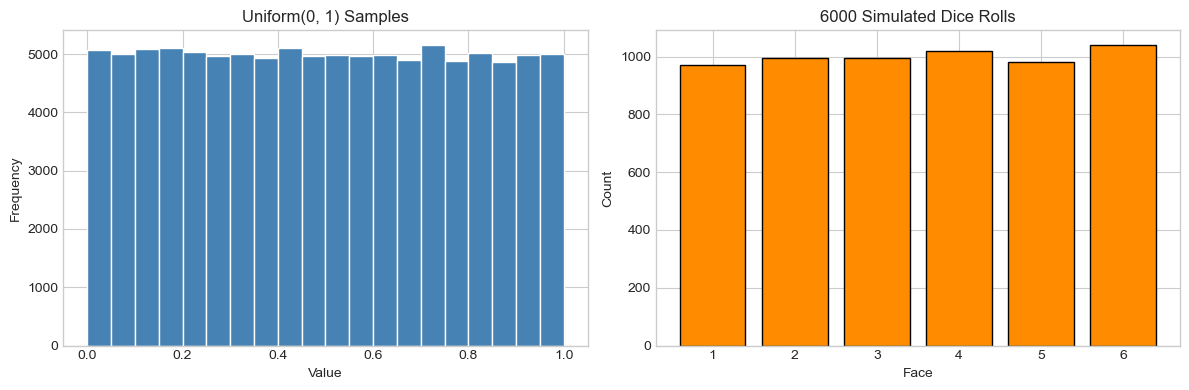

In [20]:
rng = np.random.default_rng(2026)

uniform_data = rng.random(100000)
dice_rolls = rng.integers(1, 7, size=6000)
dice_counts = np.bincount(dice_rolls, minlength=7)[1:]

print("First 8 uniform values:", np.round(uniform_data[:8], 3))
print("Dice counts for faces 1-6:", dice_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(uniform_data, bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Uniform(0, 1) Samples")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")

axes[1].bar(np.arange(1, 7), dice_counts, color="darkorange", edgecolor="black")
axes[1].set_title("6000 Simulated Dice Rolls")
axes[1].set_xlabel("Face")
axes[1].set_ylabel("Count")
axes[1].set_xticks(np.arange(1, 7))

plt.tight_layout()
plt.show()

### 9.3 Normal Distribution

The **normal distribution** is the most important continuous distribution in applied statistics.  
Heights, measurement error, test scores, and many averages are often modeled as approximately normal.

Use:
- `rng.normal(loc=mean, scale=std, size=n)`

Parameters:
- `loc`: center of the distribution (mean)
- `scale`: spread of the distribution (standard deviation)

Below, both groups have mean 70, but one group has much larger variability.

Tight group: mean=70.00, std=4.99
Wide group:  mean=70.04, std=15.00


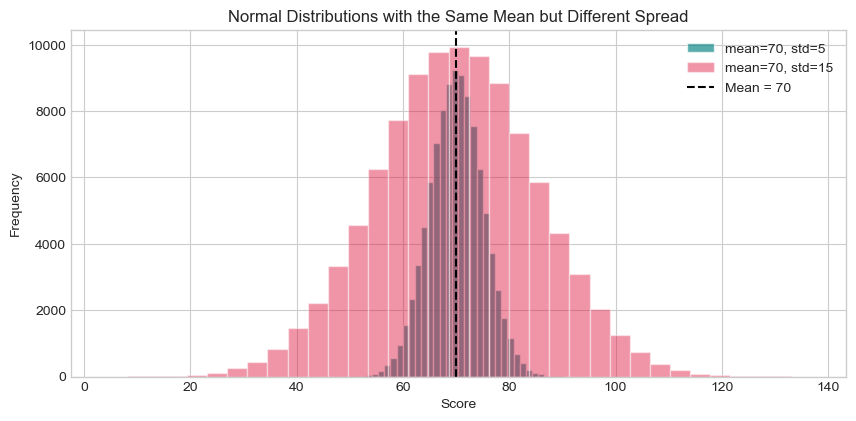

In [24]:
rng = np.random.default_rng(2026)

scores_tight = rng.normal(loc=70, scale=5, size=100000)
scores_wide = rng.normal(loc=70, scale=15, size=100000)

print(f"Tight group: mean={scores_tight.mean():.2f}, std={scores_tight.std():.2f}")
print(f"Wide group:  mean={scores_wide.mean():.2f}, std={scores_wide.std():.2f}")

plt.figure(figsize=(10, 4.5))
plt.hist(scores_tight, bins=35, alpha=0.65, label="mean=70, std=5", color="teal", edgecolor="white")
plt.hist(scores_wide, bins=35, alpha=0.45, label="mean=70, std=15", color="crimson", edgecolor="white")
plt.axvline(70, color="black", linestyle="--", linewidth=1.5, label="Mean = 70")
plt.title("Normal Distributions with the Same Mean but Different Spread")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 9.4 Discrete Distributions: Binomial and Poisson

Two common **count** distributions are:

- **Binomial**: number of successes in a fixed number of trials
  Example: number of correct answers out of 10 multiple-choice questions
- **Poisson**: number of events in a fixed interval
  Example: number of arrivals per minute or typos per page

Use:
- `rng.binomial(n, p, size)`
- `rng.poisson(lam, size)`

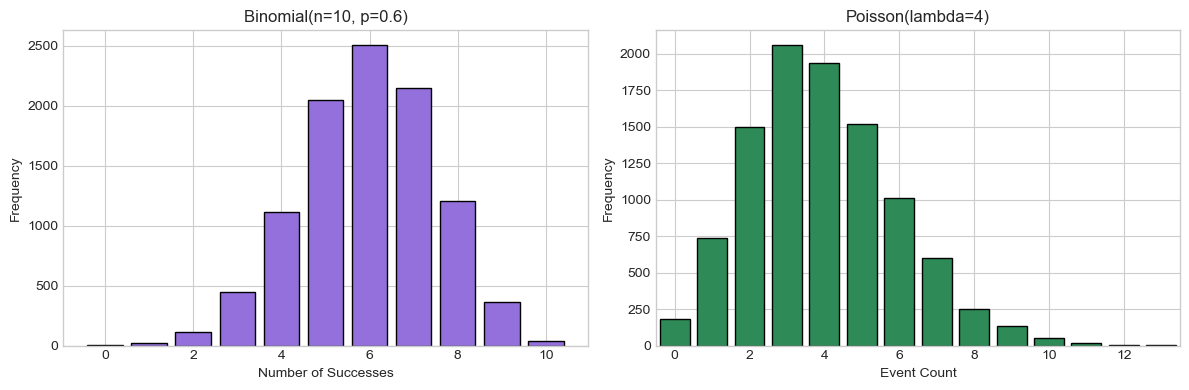

Binomial mean (theory np): 6.00, sample mean: 5.96
Poisson mean (theory lambda): 4.00, sample mean: 3.95


In [27]:
rng = np.random.default_rng(2026)

binomial_data = rng.binomial(n=10, p=0.6, size=10000)
poisson_data = rng.poisson(lam=4, size=10000)

binom_counts = np.bincount(binomial_data, minlength=11)
pois_counts = np.bincount(poisson_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(np.arange(len(binom_counts)), binom_counts, color="mediumpurple", edgecolor="black")
axes[0].set_title("Binomial(n=10, p=0.6)")
axes[0].set_xlabel("Number of Successes")
axes[0].set_ylabel("Frequency")

axes[1].bar(np.arange(len(pois_counts)), pois_counts, color="seagreen", edgecolor="black")
axes[1].set_title("Poisson(lambda=4)")
axes[1].set_xlabel("Event Count")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(-0.5, max(10, len(pois_counts) - 0.5))

plt.tight_layout()
plt.show()

print(f"Binomial mean (theory np): {10 * 0.6:.2f}, sample mean: {binomial_data.mean():.2f}")
print(f"Poisson mean (theory lambda): {4:.2f}, sample mean: {poisson_data.mean():.2f}")

### 9.5 Sampling, Shuffling, and Permutations

Generating random numbers is only part of the story.  
In practice, we often need to **sample labels**, **shuffle data order**, or **bootstrap observations**.

Key tools:
- `rng.choice()` for random sampling
- `rng.shuffle()` to shuffle an array **in place**
- `rng.permutation()` to return a shuffled **copy**

In [37]:
rng = np.random.default_rng(42)

names = np.array(["Alice", "Bob", "Charlie", "Diana", "Eve", "Frank"])

sample_no_replace = rng.choice(names, size=3, replace=False)
bootstrap_sample = rng.choice(names, size=6, replace=True)
weighted_pick = rng.choice(names, size=10, replace=True, p=[0.30, 0.10, 0.15, 0.15, 0.20, 0.10])

print(f"Sample without replacement: {sample_no_replace}")
print(f"Bootstrap sample:           {bootstrap_sample}")
print(f"Weighted sampling:          {weighted_pick}")

arr = np.array([1, 2, 3, 4, 5])
rng.shuffle(arr)
print(f"After shuffle (in place):   {arr}")

arr2 = np.array([1, 2, 3, 4, 5])
perm = rng.permutation(arr2)
print(f"Permutation (new array):    {perm}")
print(f"Original remains:           {arr2}")

Sample without replacement: ['Frank' 'Alice' 'Diana']
Bootstrap sample:           ['Frank' 'Alice' 'Eve' 'Bob' 'Alice' 'Diana']
Weighted sampling:          ['Eve' 'Eve' 'Alice' 'Charlie' 'Bob' 'Frank' 'Diana' 'Eve' 'Charlie'
 'Alice']
After shuffle (in place):   [2 1 5 4 3]
Permutation (new array):    [4 3 2 1 5]
Original remains:           [1 2 3 4 5]


### 9.6 Mini Simulation: Exam Scores

Now combine everything into a realistic example.  
We simulate exam scores from a normal distribution, clip them to the valid range `[0, 100]`, and then visualize both the score distribution and the letter-grade distribution.

> This is a useful pattern for teaching simulation before students learn formal probability theory in more depth.

n = 300
Mean   = 72.86
Std    = 12.47
Median = 73.20
Min    = 27.03
Max    = 100.00


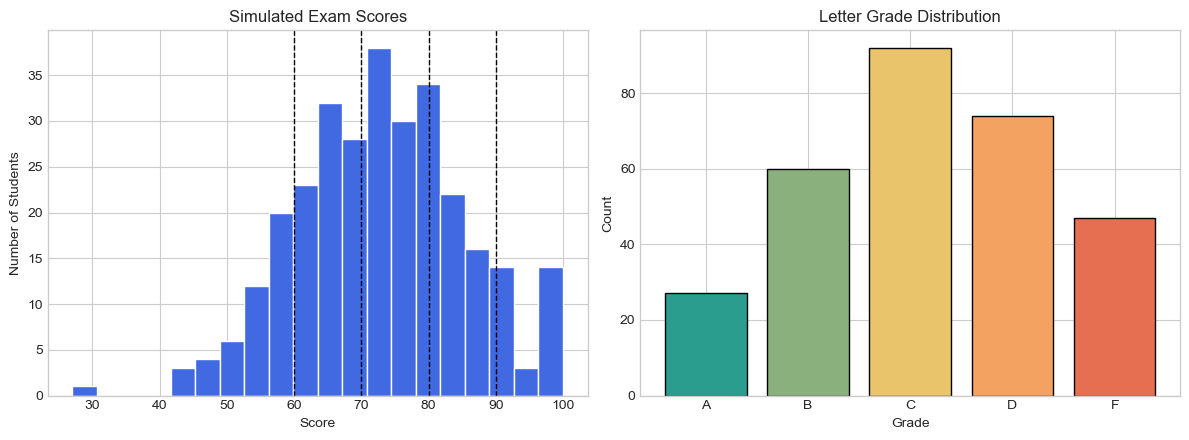

A: 27 students
B: 60 students
C: 92 students
D: 74 students
F: 47 students


In [38]:
rng = np.random.default_rng(2026)

scores = rng.normal(loc=72, scale=12, size=300)
scores = np.clip(scores, 0, 100)

conditions = [
    scores >= 90,
    scores >= 80,
    scores >= 70,
    scores >= 60,
]
choices = ["A", "B", "C", "D"]
letter_grades = np.select(conditions, choices, default="F")

grade_labels = np.array(["A", "B", "C", "D", "F"])
grade_counts = np.array([(letter_grades == g).sum() for g in grade_labels])

print(f"n = {len(scores)}")
print(f"Mean   = {scores.mean():.2f}")
print(f"Std    = {scores.std():.2f}")
print(f"Median = {np.median(scores):.2f}")
print(f"Min    = {scores.min():.2f}")
print(f"Max    = {scores.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(scores, bins=20, color="royalblue", edgecolor="white")
for cutoff in [60, 70, 80, 90]:
    axes[0].axvline(cutoff, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Simulated Exam Scores")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Number of Students")

axes[1].bar(grade_labels, grade_counts, color=["#2a9d8f", "#8ab17d", "#e9c46a", "#f4a261", "#e76f51"], edgecolor="black")
axes[1].set_title("Letter Grade Distribution")
axes[1].set_xlabel("Grade")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

for g, c in zip(grade_labels, grade_counts):
    print(f"{g}: {c} students")

---
## 10. Linear Algebra Basics

NumPy has a `linalg` sub-module for common linear algebra operations.  
These are used extensively in statistics (regression, PCA) and machine learning.

### 10.1 Dot Product and Matrix Multiplication

**Dot product** of two vectors: multiply corresponding elements and sum them up.

$$\mathbf{a} \cdot \mathbf{b} = \sum_{i} a_i b_i$$

In [39]:
# Dot product of vectors
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

dot = np.dot(a, b)  # 1*4 + 2*5 + 3*6 = 32
print(f"a · b = {dot}")
print(f"a @ b = {a @ b}")  # @ operator (Python 3.5+)

a · b = 32
a @ b = 32


**Matrix multiplication** — use the `@` operator or `np.dot()`. Remember: `(m×n) @ (n×p) → (m×p)`.

In [40]:
# Matrix multiplication
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

# Element-wise multiplication (NOT matrix multiply)
print(f"A * B (element-wise):\n{A * B}")

# Matrix multiplication
print(f"\nA @ B (matrix multiply):\n{A @ B}")

A * B (element-wise):
[[ 5 12]
 [21 32]]

A @ B (matrix multiply):
[[19 22]
 [43 50]]


### 10.2 Other Linear Algebra Operations

Determinant, inverse, eigenvalues — we'll use these in later chapters (regression, PCA).

In [41]:
A = np.array([[4, 2],
              [1, 3]])

# Determinant
det = np.linalg.det(A)
print(f"det(A) = {det:.1f}")

# Inverse
A_inv = np.linalg.inv(A)
print(f"\nA inverse:\n{A_inv}")
print(f"\nA @ A_inv (should be Identity):\n{(A @ A_inv).round(10)}")

# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"\nEigenvalues:  {eigenvalues}")
print(f"Eigenvectors:\n{eigenvectors}")

det(A) = 10.0

A inverse:
[[ 0.3 -0.2]
 [-0.1  0.4]]

A @ A_inv (should be Identity):
[[ 1.  0.]
 [-0.  1.]]

Eigenvalues:  [5. 2.]
Eigenvectors:
[[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]


**Practical example:** solving a system of linear equations using `np.linalg.solve()`.

$$2x + y = 5$$
$$x + 3y = 7$$

In matrix form: $A\mathbf{x} = \mathbf{b}$

In [28]:
# Solve Ax = b
A = np.array([[2, 1],
              [1, 3]])
b = np.array([5, 7])

x = np.linalg.solve(A, b)
print(f"Solution: x = {x[0]:.2f}, y = {x[1]:.2f}")

# Verify: A @ x should equal b
print(f"Verify: A @ x = {A @ x}")
print(f"b            = {b}")

Solution: x = 1.60, y = 1.80
Verify: A @ x = [5. 7.]
b            = [5 7]


---
## 11. Practical Example: Exam Score Analysis

Let's put everything together in a realistic data analysis scenario: analyzing exam scores for a class of students.

**Step 1:** Generate simulated data — 30 students, 4 exams.

In [43]:
rng = np.random.default_rng(2026)

n_students = 30
n_exams = 4
exam_names = ["Quiz1", "Midterm", "Quiz2", "Final"]

# Generate scores with different means for each exam
means = [75, 70, 78, 72]
stds =  [10, 15, 8, 12]

scores = np.column_stack([
    rng.normal(m, s, n_students) for m, s in zip(means, stds)
])
scores = np.clip(scores, 0, 100).round(1)

print(f"Shape: {scores.shape}  ({n_students} students × {n_exams} exams)")
print(f"\nFirst 5 students:")
print(f"{'':>5} {exam_names[0]:>8} {exam_names[1]:>8} {exam_names[2]:>8} {exam_names[3]:>8}")
for i in range(5):
    print(f"#{i+1:>3}  {scores[i,0]:>8.1f} {scores[i,1]:>8.1f} {scores[i,2]:>8.1f} {scores[i,3]:>8.1f}")

Shape: (30, 4)  (30 students × 4 exams)



First 5 students:
         Quiz1  Midterm    Quiz2    Final
#  1      67.1     52.5     70.1     79.1
#  2      77.4     90.3     70.0     48.5
#  3      56.0     82.5     70.3     50.3
#  4      89.0     87.1     66.6     56.6
#  5      81.4     56.7     70.7     73.4


**Step 2:** Descriptive statistics per exam — using `axis=0` to aggregate down columns.

In [44]:
print(f"{'Stat':<10}", end="")
for name in exam_names:
    print(f"{name:>10}", end="")
print()
print("-" * 50)

for stat_name, func in [("Mean", np.mean), ("Std", np.std),
                         ("Min", np.min), ("Median", np.median),
                         ("Max", np.max)]:
    values = func(scores, axis=0)
    print(f"{stat_name:<10}", end="")
    for v in values:
        print(f"{v:>10.2f}", end="")
    print()

Stat           Quiz1   Midterm     Quiz2     Final
--------------------------------------------------
Mean           74.97     76.05     76.71     70.76
Std             7.94     14.20      7.66     13.15
Min            56.00     52.50     64.10     44.50
Median         73.90     78.25     74.85     72.55
Max            93.20    100.00     96.00     96.40


**Step 3:** Calculate each student's weighted final grade and assign letter grades.

In [45]:
# Weights: Quiz1=10%, Midterm=30%, Quiz2=10%, Final=50%
weights = np.array([0.10, 0.30, 0.10, 0.50])
print(f"Weights: {dict(zip(exam_names, weights))}")

# Weighted average for each student (broadcasting + sum)
final_grades = (scores * weights).sum(axis=1)

print(f"\nFinal grade range: [{final_grades.min():.1f}, {final_grades.max():.1f}]")
print(f"Class average: {final_grades.mean():.1f}")
print(f"Standard deviation: {final_grades.std():.1f}")

Weights: {'Quiz1': np.float64(0.1), 'Midterm': np.float64(0.3), 'Quiz2': np.float64(0.1), 'Final': np.float64(0.5)}

Final grade range: [60.8, 88.3]
Class average: 73.4
Standard deviation: 7.5


**Step 4:** Grade distribution using boolean indexing.

In [46]:
# Assign letter grades using np.select()
conditions = [
    final_grades >= 90,
    final_grades >= 80,
    final_grades >= 70,
    final_grades >= 60,
]
choices = ["A", "B", "C", "D"]
letter_grades = np.select(conditions, choices, default="F")

print("--- Grade Distribution ---")
for grade in ["A", "B", "C", "D", "F"]:
    count = np.sum(letter_grades == grade)
    pct = count / n_students * 100
    bar = "█" * count
    print(f"Grade {grade}: {count:>2} ({pct:>5.1f}%) {bar}")

--- Grade Distribution ---
Grade A:  0 (  0.0%) 
Grade B:  7 ( 23.3%) ███████
Grade C: 10 ( 33.3%) ██████████
Grade D: 13 ( 43.3%) █████████████
Grade F:  0 (  0.0%) 


**Step 5:** Find the top 5 students and the correlation between Midterm and Final.

In [47]:
# Top 5 students
top5_idx = np.argsort(final_grades)[::-1][:5]
print("--- Top 5 Students ---")
for rank, idx in enumerate(top5_idx, 1):
    print(f"#{rank}: Student {idx+1:>2} — "
          f"Final grade: {final_grades[idx]:.1f} ({letter_grades[idx]})")

# Correlation between Midterm and Final
midterm = scores[:, 1]
final = scores[:, 3]
corr = np.corrcoef(midterm, final)[0, 1]
print(f"\nCorrelation (Midterm vs Final): {corr:.3f}")

--- Top 5 Students ---
#1: Student  6 — Final grade: 88.3 (B)
#2: Student 20 — Final grade: 86.7 (B)
#3: Student 19 — Final grade: 85.1 (B)
#4: Student 15 — Final grade: 84.4 (B)
#5: Student 26 — Final grade: 83.0 (B)

Correlation (Midterm vs Final): -0.176


---
## 12. Summary

| # | Topic | Key Functions / Concepts |
|---|-------|------------------------|
| 1 | Why NumPy | Contiguous memory, C-compiled, 10–100x faster than lists |
| 2 | Creating Arrays | `np.array()`, `zeros`, `ones`, `arange`, `linspace`, `eye` |
| 3 | Attributes | `shape`, `ndim`, `dtype`, `size` |
| 4 | Indexing | `arr[row, col]`, slicing, boolean indexing, fancy indexing |
| 5 | Vectorization | Element-wise math, no loops needed |
| 6 | Broadcasting | Arrays of different shapes, rules: equal or 1 |
| 7 | Aggregation | `mean`, `std`, `sum`, `min`, `max`, `axis` parameter |
| 8 | Reshaping | `reshape`, `flatten`, `vstack`, `hstack`, `T` |
| 9 | Random | `default_rng`, `random`, `normal`, `binomial`, `poisson`, `choice` |
| 10 | Linear Algebra | `dot`, `@`, `linalg.inv`, `linalg.solve`, `linalg.eig` |

---
## 13. Homework (Week 3a)

### Task 1: Array Practice
1. Create a 1D array of 100 random scores drawn from a normal distribution with mean=68 and std=15
2. Clip all scores to the range [0, 100]
3. Calculate: mean, median, std, min, max, Q1, Q3
4. Count how many students got each letter grade (A/B/C/D/F)
5. Find the indices of the top 10 students

### Task 2: Broadcasting Challenge
A class has 5 students with scores on 3 exams. The weights are: [0.2, 0.3, 0.5].
1. Create the scores matrix (make up the data)
2. Use broadcasting to compute each student's weighted average
3. Normalize each exam column to have mean=0 and std=1 (z-score normalization)

### Task 3: Simulation
Use `np.random` to simulate **rolling two dice 10,000 times**:
1. Calculate the sum of each roll
2. Find the probability of each possible sum (2–12)
3. Plot a bar chart or histogram of the sums
4. Find the most common sum and compare with the theoretical answer (7)

---
## Next: Week 3b — Pandas

NumPy is great for **numerical arrays**, but real data has:
- Column names ("Age", "Score", "Name")
- Mixed types (strings + numbers)
- Missing values

**Pandas** builds on NumPy to handle all of this. See you in the next notebook!

---
*Applied Statistics with Python (2026) | Week 3a | NumPy*